In [ ]:
import cv2
import os

def read_masks(folder_path, max_files=float('inf')):
    masks = []
    count = 0
    for idx, file in enumerate(os.listdir(folder_path)):
        if idx < max_files and file.endswith(".png"):
            mask = cv2.imread(os.path.join(folder_path, str(file)), cv2.IMREAD_GRAYSCALE)
            masks.append(mask)
            count += 1
    return masks[:count]

folder_path = "Data/obstacles_and_forklifts"
max_files = 1500  # Set maximum number of files to read
masks = read_masks(folder_path, max_files)

In [2]:
import numpy as np
unique_values = np.unique(np.concatenate(masks))
print(unique_values)

[  0  44  76 255]


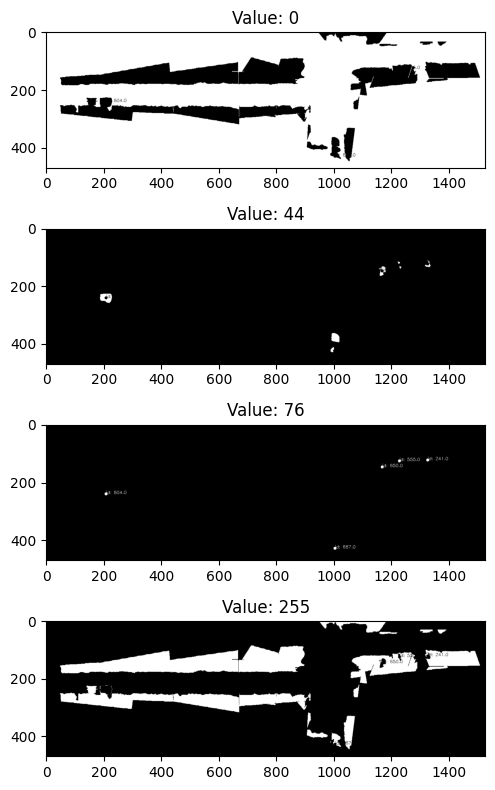

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(unique_values), figsize=(10, 8))
for i, value in enumerate(unique_values):
    idx = masks[0] == value
    subplot_img = idx.astype('uint8') * 255
    axes[i].imshow(subplot_img, cmap='gray')
    axes[i].set_title('Value: ' + str(value))
plt.tight_layout()
plt.show()

In [8]:
import networkx as nx
import numpy as np
import heapq
import matplotlib.pyplot as plt
import time

def create_graph(mask, obstacle_index = 1):
    """Create a graph from the mask where 0 represents a traversable path and 1 represents an obstacle."""
    rows, cols = mask.shape
    G = nx.Graph()
    
    for i in range(rows):
        for j in range(cols):
            if mask[i, j] == obstacle_index:  
                continue
            
            G.add_node((i, j))
            
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < rows and 0 <= nj < cols and mask[ni, nj] == 0:
                    G.add_edge((i, j), (ni, nj))

    return G

def astar(G, start, goal):
    ##A* search algorithm for shortest path
    start = tuple(map(int, start.split(",")))
    goal = tuple(map(int, goal.split(",")))
    
    if start not in G or goal not in G:
        return []

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {node: float('inf') for node in G}
    g_score[start] = 0
    f_score = {node: float('inf') for node in G}
    f_score[start] = np.linalg.norm(np.array(goal) - np.array(start))

    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal:
            break  

        for neighbor in G.neighbors(current):
            tentative_g_score = g_score[current] + 1  
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + np.linalg.norm(np.array(goal) - np.array(neighbor))
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    
    path = []
    current = goal
    while current in came_from:
        path.append(current)
        current = came_from[current]

    if path:
        path.append(start)  
    return path[::-1]  

def create_trajectory(mask, start, goal, distance):
    ### Generates a trajectory with waypoints every 'distance' pixels along the path.
    G = create_graph(mask)
    path = astar(G, start, goal)

    if not path:
        return []

    trajectory = [path[0]]
    current_dist = 0

    for i in range(1, len(path)):
        prev, curr = np.array(trajectory[-1]), np.array(path[i])
        step_dist = np.linalg.norm(curr - prev)

        if current_dist + step_dist >= distance:
            ratio = (distance - current_dist) / step_dist
            new_point = prev + ratio * (curr - prev)
            trajectory.append(tuple(map(int, new_point)))  
            current_dist = 0  
        else:
            current_dist += step_dist

    trajectory.append(path[-1])  
    return trajectory

def plot_movement(mask, trajectory, i, look_ahead, alert_pos=None):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(mask, cmap="gray", origin="upper")

    traj_x, traj_y = zip(*trajectory)
    ax.plot(traj_y, traj_x, marker="o", color="red", markersize=3, linestyle="-", linewidth=1, label="Planned Path")

    if i < len(trajectory):
        current_pos = trajectory[i]
        ax.scatter(current_pos[1], current_pos[0], color="blue", s=100, label="Current Position")

    if alert_pos:
        ax.scatter(alert_pos[1], alert_pos[0], color="orange", s=150, label="Found Obstacle Ahead!")
        ax.text(alert_pos[1], alert_pos[0], "!", fontsize=12, color="red", ha='center', va='center', fontweight='bold')

    ax.legend()
    ax.set_title(f"Frame {i + 1}")

    frame_path = f"frames/frame_{i:04d}.png"
    os.makedirs("frames", exist_ok=True)
    plt.savefig(frame_path, bbox_inches='tight')
    plt.close()

    return frame_path


def move_through_masks(mask_sequence, trajectory, look_ahead=30, output_video="output.mp4"):
    num_steps = min(len(mask_sequence), len(trajectory))  
    frame_paths = []

    for frame in range(num_steps):
        mask = mask_sequence[frame]
        print(f"Frame {frame + 1}/{num_steps}")

        i = frame  

        alert_pos = None

        for step in range(1, look_ahead + 1):  # Look ahead within range
            lookahead_index = i + step
            if lookahead_index < len(trajectory):  
                lookahead_pos = trajectory[lookahead_index]

                if mask[lookahead_pos] > 0:  # obstacle (nonzero in mask)
                    alert_pos = lookahead_pos
                    print(f"Alert: Obstacle detected at {alert_pos} in frame {frame + 1}!")
                    break  

        frame_path = plot_movement(mask, trajectory, i, look_ahead, alert_pos)
        frame_paths.append(frame_path)

    print("Completed movement")
    create_video(frame_paths, output_video)


    
def create_video(frame_paths, output_video):
    frame = cv2.imread(frame_paths[0])
    h, w, _ = frame.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_video, fourcc, 10, (w, h))

    for frame_path in frame_paths:
        frame = cv2.imread(frame_path)
        video.write(frame)

    video.release()
    print(f"Video saved as {output_video}")

    for frame_path in frame_paths:
        os.remove(frame_path)
    os.rmdir("frames")

def plot_trajectory(mask, trajectory):
    plt.figure(figsize=(10, 6))
    plt.imshow(mask, cmap="gray", origin="upper")
    
    if trajectory:
        traj_x, traj_y = zip(*trajectory)
        plt.plot(traj_y, traj_x, marker="o", color="red", markersize=5, linestyle="-", linewidth=2, label="Path")
    
    plt.legend()
    plt.title("Robot path on Mask")
    plt.show()


def animate_movement(mask_sequence, trajectory):
    import matplotlib.animation as animation
    
    fig, ax = plt.subplots()
    
    def update(frame):
        ax.clear()
        mask = mask_sequence[frame]
        
        ax.imshow(mask, cmap="gray", origin="upper")

        traj_x, traj_y = zip(*trajectory)
        ax.plot(traj_y, traj_x, marker="o", color="red", markersize=3, linestyle="-", linewidth=1, label="Planned Path")

        if frame < len(trajectory):
            current_pos = trajectory[frame]
            ax.scatter(current_pos[1], current_pos[0], color="blue", s=100, label="Current Position")

        if frame + 2 < len(trajectory):
            lookahead_pos = trajectory[frame + 2]
            if mask[lookahead_pos] == 1:
                ax.scatter(lookahead_pos[1], lookahead_pos[0], color="orange", s=150, label="Obstacle Ahead!")
        
        ax.legend()
        ax.set_title(f"Frame {frame + 1}/{len(mask_sequence)}")

    ani = animation.FuncAnimation(fig, update, frames=len(mask_sequence), interval=500, repeat=False)
    plt.show()

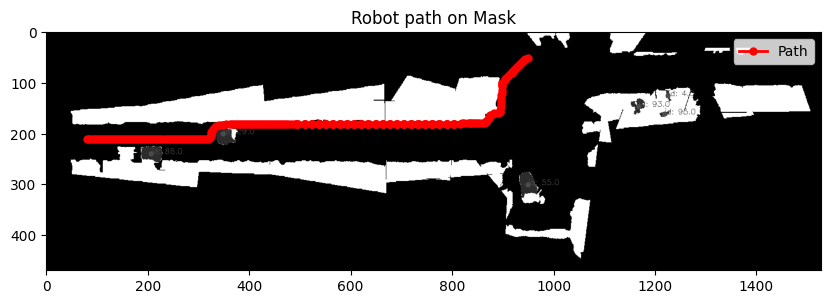

In [9]:
num_frames = 500
mask_sequence = masks[0:num_frames]

#start = "210,80"
#goal = "70,1420"
#distance = 10

#trajectory = create_trajectory(masks[10], start, goal, distance)
#plot_trajectory(masks[10], trajectory)
# move_through_masks(mask_sequence, trajectory)

start = "210,80"
goal = "50,950"
distance = 25

trajectory = create_trajectory(masks[10], start, goal, distance)
plot_trajectory(masks[10], trajectory)


In [10]:
move_through_masks(mask_sequence, trajectory, output_video="simulation_path.mp4")

Frame 1/254
Frame 2/254
Frame 3/254
Frame 4/254
Frame 5/254
Frame 6/254
Alert: Obstacle detected at (210, 135) in frame 6!
Frame 7/254
Frame 8/254
Frame 9/254
Frame 10/254
Frame 11/254
Frame 12/254
Frame 13/254
Alert: Obstacle detected at (210, 131) in frame 13!
Frame 14/254
Frame 15/254
Frame 16/254
Frame 17/254
Frame 18/254
Frame 19/254
Frame 20/254
Frame 21/254
Alert: Obstacle detected at (210, 259) in frame 21!
Frame 22/254
Frame 23/254
Frame 24/254
Frame 25/254
Frame 26/254
Frame 27/254
Frame 28/254
Frame 29/254
Frame 30/254
Frame 31/254
Frame 32/254
Frame 33/254
Frame 34/254
Frame 35/254
Frame 36/254
Frame 37/254
Frame 38/254
Alert: Obstacle detected at (208, 323) in frame 38!
Frame 39/254
Frame 40/254
Frame 41/254
Frame 42/254
Frame 43/254
Frame 44/254
Frame 45/254
Frame 46/254
Frame 47/254
Frame 48/254
Frame 49/254
Alert: Obstacle detected at (194, 326) in frame 49!
Frame 50/254
Frame 51/254
Frame 52/254
Frame 53/254
Frame 54/254
Frame 55/254
Frame 56/254
Frame 57/254
Frame 58/